In [435]:
from numba import jit, njit
import kwant
from kwant.digest import uniform    # a (deterministic) pseudorandom number generator
import kwant.kpm


import scipy

import numpy as np
import matplotlib.pyplot as plt
from types import SimpleNamespace

from scipy.ndimage import gaussian_filter

from matplotlib.colors import LinearSegmentedColormap



import cmath

from qutip import *
from joblib import Parallel, delayed

In [436]:
def corr_dis(L, W, a, xic):
    Nx = int(L/a)
    Ny = int(W/a)
    Vxy = np.random.normal(0, 1., size=(Ny, Nx))/(a) + 1j*0.0
    
    kkVxy = np.fft.fft2(Vxy)
    kx = 2*np.pi * np.fft.fftfreq(kkVxy.shape[1],d=a)
    ky = 2*np.pi * np.fft.fftfreq(kkVxy.shape[0],d=a)
    kx, ky = np.meshgrid(kx,ky)
    
    kVxy = np.multiply(kkVxy, np.exp( - .125 * xic**2. * (kx**2.+ky**2.)  ) ) * xic/np.sqrt(2.)
    
    Vxy = np.fft.ifft2(kVxy)
    Vxy = Vxy - np.sum(Vxy)/(1.*Nx*Ny)

    return Vxy

In [437]:
def v_img_singleside(W, N, min_l):
    arr_x = np.linspace(min_l, W+min_l, N)
    arr_V = - 1./(np.abs( np.flip(arr_x) ))
    return arr_V


def v_img(W, N, min_l):
    arr_V = []
    arr_x = np.linspace(-W/2, W/2, N)
    d = 1000*W + 2*min_l
    for x in arr_x:
        V = 0
        nf = 50000
        n_Z = np.linspace( -nf, nf, 2*nf+1)
        for n in n_Z:
            if n != 0:
                V += ( 1./(2*np.abs(n)) - 1./(2.*np.abs(n+500*(x)/d )) )
        if x < 0:
            arr_V.append(V)
        else:
            arr_V.append(V)
    return np.asarray(arr_V)/d*1000


def v_expcutoff_img_singleside(W, N, min_l, xiV):
    arr_x = np.linspace(min_l, W+min_l, N)
    arr_V = - 1./(np.abs( np.flip(arr_x) ))*np.exp( -(np.abs((np.flip(arr_x-0*min_l)))/xiV)**1/(2) )
    #arr_V = - 1./(np.abs( arr_x )) /( np.exp( (arr_x-min_l - xiV)/(.01*xiV) ) + 1 )
    return arr_V

def fourth_conf(L, W):
    Vxy = np.zeros(shape=(W, L), dtype=np.complex_)
    xvec = np.linspace(0, W-1, int(W) )
    yvec = np.linspace(0, L-1, int(L) )    
    for nx in range(W):
        for ny in range(L): 
            Vxy[nx][ny] = 16*( xvec[nx]/W - 1/2. )**4
    return Vxy

def tan_confinement(L, W, dr, Wedge, A):
    Vxy = np.zeros(shape=(W, L), dtype=np.complex_)
    Nedge = int(Wedge/dr)
    xvec = np.linspace(0, W-1, int(W) )
    yvec = np.linspace(0, L-1, int(L) )    
    
    
    minRx = np.amin(xvec)
    maxRx = np.amax(xvec)
    for nx in range(W):
        for ny in range(L):
            if xvec[nx] <= (Wedge + minRx):
                Vxy[nx][ny] = (np.tan(A * np.pi/2.*( xvec[nx] - (Wedge + minRx) )/Wedge  ) )**2.
            elif xvec[nx] >= (maxRx-(Wedge)):
                Vxy[nx][ny] = (np.tan(A * np.pi/2.*( xvec[nx] - (maxRx-(Wedge) + dr/2.  ) )/Wedge  ) )**2.
    
    return np.sqrt(Vxy)

In [438]:

# Energy-Length-Magnetic scale (arbitrary) just to have a dimensional reference for the parameters
#a=0.6 # real lattice spacing in GaAs, in nm
#BandW0 = 40   #total bandwidth in meV
#l0 = np.sqrt(568/BandW0*8.) * 10**(-3.) # effective lattice spacing sqrt( \hbar^2/(2m*)/(\hbar J)) here I took \hbar^2/(2m*) = 568 nm^2 meV (GaAs) and \hbar J = BW/8 in micron!
#B0 = 4.14*10**3. / (l0 * 10**3.)**2. #in T, as 2\pi \hbar/e 1/a^2


lat = kwant.lattice.square(a=1, norbs=1)
iter_dis = 1
t = 1   # hopping rate for kwant
W = 50  # spatial width of the system ( Nx )
L = 40  # spatial length of the system ( Ny )

alpha = 1/30
lB = 1./np.sqrt(2*np.pi*alpha)
omB = 4*np.pi*alpha

Nelect = 5*alpha*(W-1)*(L-1)



xic = lB * 1      # Correlation length and definition of disorder-potential array
Vdis = corr_dis(int(L), int(W), 1, xic)
plate_distance = 10*lB      #edge-plate distance
Vimg = v_img_singleside(W, int(W), plate_distance)   # normalized image potential single plate
#Vimg = v_expcutoff_img_singleside(W, int(W), plate_distance, 6*lB)
V_img_min = np.amin(Vimg)
Vimg = Vimg - V_img_min - lB/plate_distance**2 
#E_img = omB*lB * ( (plate_distance/lB)**2 ) / 3.         # Image charge amplitude in Zeeman
E_img = omB*lB * 0
E_dis = omB * .2                # disorder amplitude in cyclotrons


#Vconf = fourth_conf(L, W) * 1.3*omB
Vconf = tan_confinement(L, W, 1, int(W/7), .5)

def onsite(site, params):
    xi, yi = site.pos

    om0 = 4 * t  # Original onsite energy
    omRan = params.E_dis * params.V[int(xi)][int(yi)]  # Disorder
    omConf = params.Vconf[int(xi)][int(yi)]
    omImg = params.E_img * Vimg[int(xi)]  # Image charge

    return om0 + omRan + omImg + omConf

def hopping(site_i, site_j, params):
    xi, yi = site_i.pos
    xj, yj = site_j.pos

    #phase = -1j * 2 * np.pi * params.alpha * (xi - xj) * (yi + yj) / 2.
    if np.abs(yi - yj) < 1.1:
        phase = -1j * 2 * np.pi * params.alpha * (xi + xj) * (yi - yj) / 2.
    else:
        phase = -1j * 2 * np.pi * params.alpha * (xi + xj) * (1) / 2.
    
    return -t * np.exp(phase)

def onsite_lead(site, params):
    return 4 * t

def hopping_lead(site_i, site_j, params):
    return -t 

sys = kwant.Builder()
#sym_y = kwant.TranslationalSymmetry((0, L))
#sys = kwant.Builder(sym_y)

sys[(lat(x, y) for x in range(W) for y in range(L))] = onsite
sys[lat.neighbors()] = hopping


for x in range(W): # PBC along y
    sys[lat(x, 0), lat(x, L-1)] = hopping  # connect top <-> bottom
    
#for y in range(L): # PBC along x
#    sys[lat(0, y), lat(W-1, y)] = hopping  # connect top <-> bottom


#kwant.wraparound.wraparound(sys, keep=(0,))

sys = sys.finalized()



params =SimpleNamespace( alpha=alpha, E_dis=E_dis, E_img=0, V=Vdis, Vimg=Vimg, Vconf=Vconf )
params_img = SimpleNamespace( alpha=alpha, E_dis=E_dis, E_img=E_img, V=Vdis, Vimg=Vimg, Vconf=Vconf )

ham_mat = sys.hamiltonian_submatrix( sparse=True, args=[params])


/var/folders/y4/dpq6l9fj2kv9z0prq_6_pyy00000gn/T/ipykernel_29535/352163358.py:89: KwantDeprecationWarning:

The 'args' parameter has been deprecated since version 1.4 -- Instead, provide named parameters as a dictionary via 'params'.



(0.9999999999999999+0j)


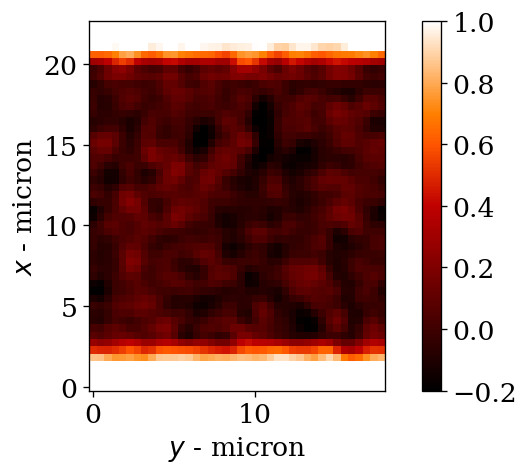

In [439]:
xvec = np.linspace(0, W-1, int(W) )
yvec = np.linspace(0, L-1, int(L) )
X, Y = np.meshgrid(yvec, xvec)

fig_conf, ax_conf = plt.subplots(dpi=120, figsize=(8, 4))

vmin = -E_dis/omB
vmax = 1.000
conf_plot = ax_conf.pcolormesh(X*1/lB, Y*1/lB, (Vconf.real/omB + E_dis*Vdis.real/omB), cmap='gist_heat', alpha=1, vmin=vmin, vmax=vmax)

fig_conf.colorbar(conf_plot)

ax_conf.set_xlabel(r'$y$ - micron')
ax_conf.set_ylabel(r'$x$ - micron')
ax_conf.set_aspect('equal')
print(np.amax(Vconf) )

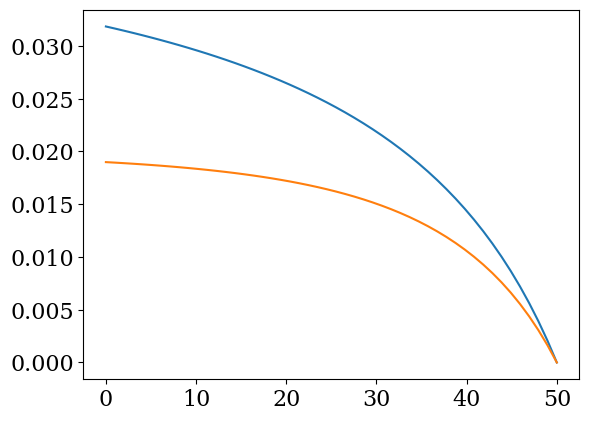

In [440]:
VII = v_img_singleside(W, int(W), 10*lB)
VIIex = v_expcutoff_img_singleside(W, int(W), 10*lB, 6*lB)
plt.plot(np.linspace(0, W, W), VII-np.amin(VII))
plt.plot(np.linspace(0, W, W), VIIex-np.amin(VIIex))

In [441]:
ham_mat.shape

(2000, 2000)

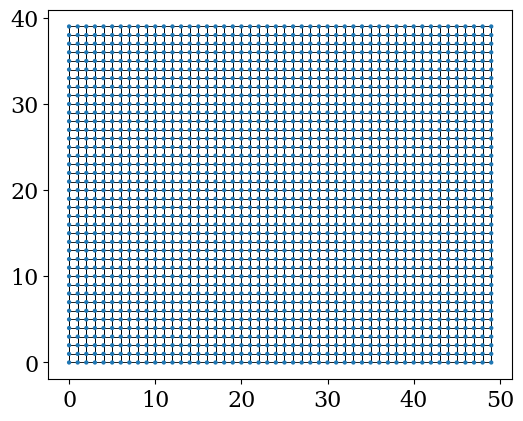

In [442]:
kwant.plot(sys);

In [443]:
import scipy.linalg

Ntot_e = 1600

ham_dense = ham_mat.toarray()
#evals, evecs = np.linalg.eig(ham_dense)
evals, evecs = scipy.sparse.linalg.eigs(ham_mat.tocsc(), k=Ntot_e, sigma=0)



In [444]:

idx = np.argsort(evals)
evals = evals[idx]
evecs = evecs[:,idx]

In [445]:
positions = np.array([site.pos for site in sys.sites])
x_coords = positions[:, 0]

# Repeat each coordinate for the spin degrees of freedom
num_spin = 1
x_coords_spinful = np.repeat(x_coords, num_spin)

# Compute <x> for each eigenstate
x_avg = np.sum(np.abs(evecs)**2 * x_coords[:, np.newaxis], axis=0)

/opt/anaconda3/lib/python3.12/site-packages/matplotlib/collections.py:194: ComplexWarning:

Casting complex values to real discards the imaginary part



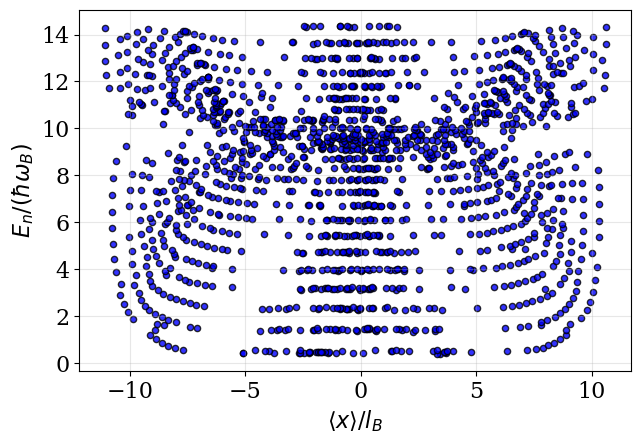

In [446]:

# --- Re-use your style settings ---
font = {
    'family': 'serif',
    'color': 'black',
    'weight': 'normal',
    'size': 16,
}
plt.rcParams['font.family'] = font['family']
plt.rcParams['font.size'] = font['size']
plt.rcParams['axes.labelsize'] = font['size']
plt.rcParams['xtick.labelsize'] = font['size']
plt.rcParams['ytick.labelsize'] = font['size']

# --- Your existing data (example variables) ---
# x_avg, evals, W, lB, omB must be defined as before

# --- Create the styled plot ---
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter((x_avg - W/2)/lB, evals/omB,
           s=20,                # marker size
           color='blue',         # match main-figure palette
           edgecolor='black',   # thin border for clarity
           alpha=0.8)

ax.set_xlabel(r'$\langle x \rangle / l_B$', fontdict=font)
ax.set_ylabel(r'$E_n / (\hbar \omega_B)$', fontdict=font)
#ax.set_title('Eigenvalues vs average x-position', fontdict=font, pad=10)

# Match grid and limits style
ax.grid(True, alpha=0.3)
#ax.set_xlim(-26, 26)

# Optional: match paper figure width (≈170 mm)
fig.set_size_inches(170 / 25.4, 120 / 25.4)
plt.tight_layout()

#ax.set_ylim(0.4,1)
#plt.savefig('spec_cazzillo_scheme.pdf')
plt.show()

In [447]:
XXX = np.matmul( np.conj(evecs.T), np.matmul(np.diag(positions[:, 0]), evecs) )

#YYY = np.matmul( np.conj(evecs.T), np.matmul(np.diag((R[:,0]-Nx/2.)**2.), evecs) )


In [448]:
vecX = np.abs(np.diagonal(XXX))
J = 1
dis = E_dis

BW = 20 #in meV
l0 = np.sqrt(568/BW*8.) * 10**(-3.) # sqrt( \hbar^2/(2m*)/(\hbar J)) here I took \hbar^2/(2m*) = 568 nm^2 meV (GaAs) and \hbar J = BW/8 in micron!
B0 = 4.14*10**3. / (l0 * 10**3.)**2. #in T, as 2\pi \hbar/e 1/a^2

EGS = evals[0]

Nx = W
Ny = L



/var/folders/y4/dpq6l9fj2kv9z0prq_6_pyy00000gn/T/ipykernel_29535/3597379069.py:17: RuntimeWarning:

divide by zero encountered in log

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


2.002599401875602


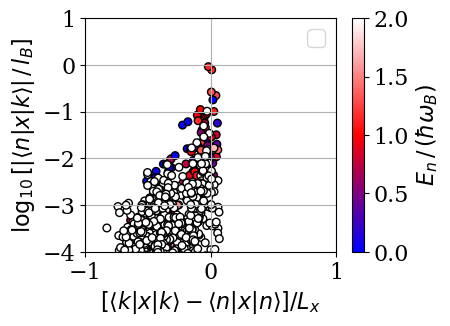

In [449]:
N = 1
n0 = 250
X = []
Y = []
Z = []

for ni in range(n0, N+n0):
    arr_VV = []
    for n in range(evals.size):
        if n != ni:
            arr_VV.append(np.abs(XXX[n][ni]))
        else:
            arr_VV.append(0)
    arr_VV = np.asarray(arr_VV)
    
    X.append((vecX - vecX[ni]) / Nx)
    Y.append(np.log(arr_VV / lB) / np.log(10.))
    Z.append(np.abs(evals - evals[ni]) / omB)
    print(np.amax(arr_VV))

# Create a custom colormap from blue to red to white
colors = [(0, 0, 1), (1, 0, 0), (1, 1, 1)]  # Blue -> Red -> White
n_bins = 100  # Number of color bins
cmap_name = 'blue_red_white'
cm = LinearSegmentedColormap.from_list(cmap_name, colors, N=n_bins)

# Create the figure with the desired size
fig, ax = plt.subplots(figsize=(120 / 25.4, 90 / 25.4))

vmin = 0
vmax = 2

# Plot each set of X, Y, Z
for i in range(N):
    XN = (X[i])
    YN = (Y[i])
    ZN = (Z[i])
    sc = ax.scatter(XN, YN, c=ZN, cmap=cm, edgecolor='k', vmin=vmin, vmax=vmax, s=30)

# Set limits, labels, and title with the desired font style
font = {'family': 'serif', 'color': 'black', 'weight': 'normal', 'size': 16}

# Add colorbar
cbar = plt.colorbar(sc)
cbar.set_label(r'$E_n\, / \, (\hbar \omega_B)$', fontdict=font)

ax.set_ylim((-4, 1))
ax.set_xlim((-1., 1.))
ax.set_xlabel(r'$\left[ \langle{k|x|k\rangle} - \langle{n|x|n\rangle}\right]/L_x$', fontdict=font)
ax.set_ylabel(r'$\log_{10}\left[ |\langle{n|x|k\rangle}|\,/\,l_B \right]$', fontdict=font)
#ax.set_title('Matrix element X', fontdict=font)

# Add grid and legend
ax.grid(True)
ax.legend()

# Adjust layout and save the figure
plt.tight_layout()
#plt.savefig('Xnk_vs_X_Lx_n%d_Nx%d_Ny%d_BW%.2f_alpha%.2f_dis%.2f_xic%.2f.svg' % (n0, Nx, Ny, BW, alpha, dis, xic))
#plt.savefig('Xnk_vs_X_Lx_n%d_Nx%d_Ny%d_BW%.2f_alpha%.2f_dis%.2f_xic%.2f.pdf' % (n0, Nx, Ny, BW, alpha, dis, xic))
# Show plot
plt.show()

In [450]:
n0 = 2

6.204417917448533


/var/folders/y4/dpq6l9fj2kv9z0prq_6_pyy00000gn/T/ipykernel_29535/1869217865.py:20: RuntimeWarning:

divide by zero encountered in log



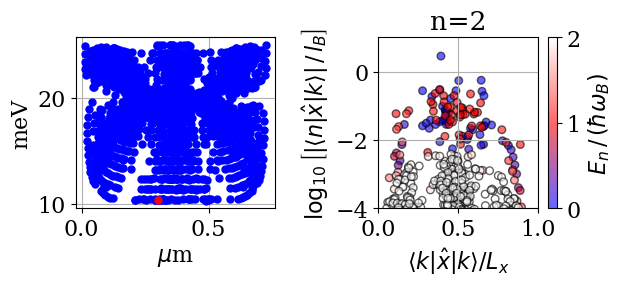

In [451]:

LL = 1
omB_corr = 4 * np.pi * alpha * J * LL - (4 * np.pi * alpha * J) ** 2 / (32. * J) * (2 * LL ** 2. + 2. * LL + 1.)
omB_corr_dis = omB_corr + dis * xic / lB / np.sqrt(2 * np.pi * (2 + (xic / lB) ** 2.)) / 2

N = 1
X = []
Y = []
Z = []

for ni in range(n0, N + n0):
    arr_VV = []
    for n in range(evals.size):
        if n != ni:
            arr_VV.append(np.abs(XXX[n][ni]))
        else:
            arr_VV.append(0)
    arr_VV = np.asarray(arr_VV)
    
    X.append((vecX - 0*vecX[ni]) / Nx)
    Y.append(np.log(arr_VV / lB) / np.log(10.))
    Z.append(np.abs(evals - evals[ni]) / omB)
    print(np.amax(arr_VV))

# Create a custom colormap from blue to red to white
colors = [(0, 0, 1), (1, 0, 0), (1, 1, 1)]  # Blue -> Red -> White
n_bins = 100  # Number of color bins
cmap_name = 'blue_red_white'
cm = LinearSegmentedColormap.from_list(cmap_name, colors, N=n_bins)

# Create the figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(170 / 25.4, 80 / 25.4))  # 240 mm by 90 mm figure

# Plot 1
ax1.plot(np.abs(np.diagonal(XXX)) * l0, ( evals.real + EGS + 4 - omB_corr_dis / 2. ) * BW / 8., linestyle='none', marker='o', color='blue', ms=5)
#ax1.plot(np.abs(np.diagonal(XXX)) * l0, np.ones(np.abs(np.diagonal(XXX)).size) * (omB_corr_dis) * BW / 8., color='red')
ax1.plot(np.abs(XXX[n0][n0]) * l0, ( evals[n0].real + EGS + 4 - omB_corr_dis / 2. ) * BW / 8., linestyle='none', marker='o', color='red', ms=5)

# Axis limits, labels, and grid for Plot 1
#ax1.set_ylim((-.5, 3))
ax1.set_xlabel(r'$\mu$m', fontdict={'family': 'serif', 'color': 'black', 'weight': 'normal', 'size': 16})
ax1.set_ylabel(r'meV', fontdict={'family': 'serif', 'color': 'black', 'weight': 'normal', 'size': 16})
ax1.grid(True)

# Plot 2
from matplotlib.colors import Normalize

for i in range(N):
    XN = (X[i])
    YN = (Y[i])
    ZN = (Z[i])
    
    """norm = Normalize(vmin=0, vmax=1)
    cmap_vals = cm(norm(ZN))  # shape (N, 4), includes RGBA
    alphas = 1.0 - 0.8 * norm(ZN)  # alpha decreases as ZN increases
    # Replace the alpha (4th channel) in colormap with custom alpha values
    colors_with_alpha = cmap_vals.copy()
    colors_with_alpha[:, -1] = alphas  # set alpha channel
    # Now plot with pre-computed RGBA colors
    sc = ax2.scatter(XN, YN, color=colors_with_alpha, edgecolor='k', s=30)"""


    #sc = ax2.scatter(XN, YN, c=ZN, cmap=cm, edgecolor='k', vmin=0, vmax=2, s=30, alpha=None)
    #sc.set_alpha(None)  # Ensure individual alpha per point is used
    #sc.set_facecolors([(r, g, b, a) for (r, g, b, _), a in zip(cm(norm(ZN)), alphas)])
    sc = ax2.scatter(XN, YN, c=ZN, cmap=cm, edgecolor='k', vmin=0, vmax=2, s=30, alpha=0.6)

# Add colorbar for Plot 2
cbar = plt.colorbar(sc, ax=ax2)
cbar.set_label(r'$E_n\, / \, (\hbar \omega_B)$', fontdict={'family': 'serif', 'color': 'black', 'weight': 'normal', 'size': 16})

# Axis limits, labels, and grid for Plot 2
ax2.set_ylim((-4, 1))
ax2.set_xlim((-0., 1.))
ax2.set_xlabel(r'$\langle{k|\hat{x}|k\rangle}/L_x$', fontdict={'family': 'serif', 'color': 'black', 'weight': 'normal', 'size': 16})
ax2.set_ylabel(r'$\log_{10}\left[ |\langle{n|\hat{x}|k\rangle}|\,/\,l_B \right]$', fontdict={'family': 'serif', 'color': 'black', 'weight': 'normal', 'size': 16})
ax2.grid(True)

# Adjust layout and display the figure
ax2.set_title('n=%d'%(n0))
plt.tight_layout()
#plt.savefig('Xnk_vs_X_Lx_n%d_Nx%d_Ny%d_BW%.2f_alpha%.2f_dis%.2f_xic%.2f.svg' % (n0, Nx, Ny, BW, alpha, dis, xic))
#plt.savefig('Xnk_vs_X_Lx_n%d_Nx%d_Ny%d_BW%.2f_alpha%.2f_dis%.2f_xic%.2f.pdf' % (n0, Nx, Ny, BW, alpha, dis, xic))
plt.show()

In [452]:
#x2_vec = np.diagonal(YYY)

In [453]:
#plt.plot(evals/omB, x2_vec, marker='o', linestyle='none')
#plt.xlim(0,.3)


In [454]:

x_elms = XXX/lB - W/lB/2.*np.diag(np.ones(len(evals)))
#np.fill_diagonal(x_elms, 0)

E = ( evals  - evals[0] )/ omB
M = E[:, np.newaxis] - E
M = M.T
#M[np.abs(M) <= 0.75] = 0.0

omc = 1.

@njit
def heff(E, M, x, omc):
    Nh = np.argmin(np.abs(E-.75))
    N_2L = np.argmin(np.abs(E-1.75))
    h = np.zeros( shape=(Nh,Nh), dtype=np.complex_ )
    X_p = np.zeros( shape=(Nh,Nh), dtype=np.complex_ )
    res_X = np.zeros( shape=(Nh,Nh), dtype=np.complex_ )
    for n in range(Nh):
        for m in range(Nh):
            if n==m:
                    h[n][m] += .25 / omc #A^2 term in Coulomb
            for k in range(int(len(E)/2-1)):
                
                
                #h[n][m] += x[n][k]*x[k][m] * M[n][k] /(M[n][k] + omc +0j)/2 + x[n][k]*x[k][m] * M[m][k] /(M[m][k] + omc + 0j)/2 
                
                h[n][m] +=  - x[n][k]*x[k][m] * M[k][n]*M[k][m] /(M[n][k] + omc +0j)/2 - x[n][k]*x[k][m] * M[k][m]*M[k][n] /(M[m][k] + omc + 0j)/2 #2nd order term in Coulomb
                
                if k > Nh and k < N_2L:
                    #X_p[n][m] +=  - x[n][k]*x[k][m] * M[k][n]*M[k][m] /(M[n][k] + omc +0j)/2 - x[n][k]*x[k][m] * M[k][m]*M[k][n] /(M[m][k] + omc + 0j)/2
                    X_p[n][m] +=  - x[n][k]*x[k][m]/2 #/(M[n][k] + omc +0j)/2 - x[n][k]*x[k][m]/(M[m][k] + omc + 0j)/2
                if k < Nh and k!=n and k!=m:    
                    
                    #res_X[n][m] +=  -  x[n][k]*x[k][m] * M[k][n]*M[k][m] /(M[n][k] +omc +0j)/2 - x[n][k]*x[k][m] * M[k][m]*M[k][n] /(M[m][k] +omc + 0j)/2
                    res_X[n][m] +=  - x[n][k]*x[k][m] * M[k][n]*M[k][m] /(omc +0j)
                
                #h[n][m] += x[n][k]*x[k][m] /( omc +0j) * omc
                #h[n][m] += - x[n][k]*x[k][m] /(M[n][k] + omc +0j)/2 * omc - x[n][k]*x[k][m]  /(M[m][k] + omc + 0j)/2 * omc
                
                #if k != n and k != m :
                #    h[n][m] += x[n][k]*x[k][m] /( omc +0j) * omc
                #    h[n][m] += - x[n][k]*x[k][m] /(M[n][k] + omc +0j)/2 * omc - x[n][k]*x[k][m]  /(M[m][k] + omc + 0j)/2 * omc
        
    return (np.conj(h.T) + h), np.diag(E[:Nh]), (X_p+np.conj(X_p.T)), (res_X+np.conj(res_X.T))

Heff, H0, X_p, res_X = heff(E, M, x_elms, omc)

In [455]:
a = 10

evalseff, eveceff = np.linalg.eig(  a *Heff + H0)
idx = np.argsort(evalseff)
evalseff = evalseff[idx]
eveceff = eveceff[:, idx]

x_eff = np.zeros(len(evalseff))

for n in range(len(evalseff)):
    x_eff[n] = np.matmul(np.conj(eveceff[:,n].T), np.matmul(x_elms[:len(evalseff),:len(evalseff)], eveceff[:,n]))


/var/folders/y4/dpq6l9fj2kv9z0prq_6_pyy00000gn/T/ipykernel_29535/279868205.py:11: ComplexWarning:

Casting complex values to real discards the imaginary part



/opt/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1699: ComplexWarning:

Casting complex values to real discards the imaginary part

/opt/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1345: ComplexWarning:

Casting complex values to real discards the imaginary part



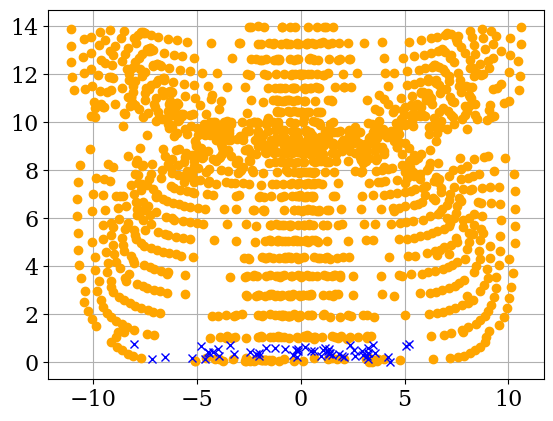

In [456]:
Nev1 = Ntot_e-1
plt.plot(np.diagonal(x_elms)[:Nev1], (evals[:Nev1].real-evals[0].real)/omB, linestyle='none', marker='o', color='orange')
plt.plot(x_eff, evalseff-evalseff[0], linestyle='none', marker='x', color='blue')

x_arr = np.linspace(np.amin(x_eff), np.amax(x_eff), 30)
#plt.plot(x_arr, 1./(1+omc)*np.ones(len(x_arr)), color='black')
cent_er = ( .25*dis/omB + .03*0 )
#plt.plot(x_arr, a/(1+omc)*np.ones(len(x_arr)) + cent_er, color='red' )

#plt.plot(x_arr, a/(1+omc)*np.ones(len(x_arr)) + .25*dis/omB +   a*2*(dis/omB)* (lB/Nx)**2 *(x_arr-0*np.amax(x_arr)/2)**2 + cent_er, color='blue' )
#plt.plot(x_arr, a/(1+omc)*np.ones(len(x_arr)) - .25*dis/omB -   a*2*(dis/omB)* (lB/Nx)**2 *(x_arr-0*np.amax(x_arr)/2)**2 + cent_er, color='blue' )


#plt.ylim(-.1,.5)
#plt.xlim(30,60)
plt.grid()


In [457]:
print(np.amax(positions[:,0]), Nx, lB)

49.0 50 2.1850968611841584


In [458]:
#Kn = np.sum(np.square(np.abs(Heff - np.eye(len(Heff))*.25 / omc)), axis=0 )
Kn = np.zeros( Heff.shape[0] )
Xn = np.zeros( Heff.shape[0] )
Rn = np.zeros( Heff.shape[0] )
Tn = np.zeros( Heff.shape[0] )


for n in range(Heff.shape[0]):
    for m in range(Heff.shape[0]):
        if n!= m:
            Kn[n] += np.square(np.abs( Heff[m][n]))
            Xn[n] += np.square(np.abs( X_p[m][n]))
            Rn[n] += np.square(np.abs( res_X[m][n]))
            Tn[n] += np.square(np.abs( X_p[m][n] + res_X[m][n]))
            

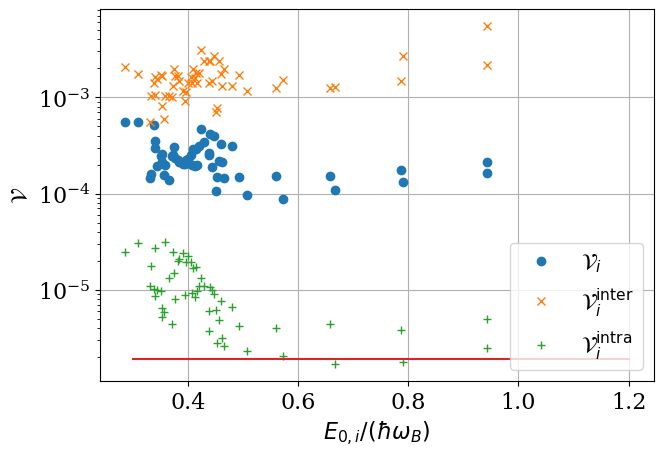

In [459]:
Gamm = 2*dis * xic / lB / np.sqrt( 2*np.pi* (2 + (xic / lB) ** 2.))



# Font configuration
font = {
    'family': 'serif',
    'color': 'black',
    'weight': 'normal',
    'size': 16,
}
# Apply the font globally
plt.rcParams['font.family'] = font['family']
plt.rcParams['font.size'] = font['size']
plt.rcParams['axes.labelsize'] = font['size']
plt.rcParams['xtick.labelsize'] = font['size']
plt.rcParams['ytick.labelsize'] = font['size']

fig, (ax1) = plt.subplots(1, 1, figsize=(8, 8))


ax1.plot( (evals[0:len(Kn)] )/ omB - Gamm/omB, Kn, marker='o', linestyle='none', label=r'$\mathcal{V}_i$')
ax1.plot( (evals[0:len(Kn)] )/ omB - Gamm/omB, Xn, marker='x', linestyle='none', label=r'$\mathcal{V}_i^{\rm inter}$')
ax1.plot( (evals[0:len(Kn)] )/ omB - Gamm/omB, Rn, marker='+', linestyle='none', label=r'$\mathcal{V}_i^{\rm intra}$')

vEs = np.linspace(0.3,1.2,10)
BB = (1/(omc-E_dis/omB))**2*(E_dis/omB/6)**4
ax1.plot(vEs, BB*np.ones(len(vEs)))


ax1.set_ylabel(r"$\mathcal{V}$", fontdict=font)
ax1.set_xlabel(r"$E_{0,i}/(\hbar\omega_B)$", fontdict=font)
ax1.legend(loc='lower right', fontsize=16)
plt.yscale('log')
#plt.xlim(-.05,.05)
#plt.ylim(1e-9, 1e-0)
plt.grid()


plt.tight_layout()
plt.gcf().set_size_inches(170 / 25.4, 110 / 25.4)

#plt.savefig('vacuum_spread.pdf')

(1e-06, 1.0)

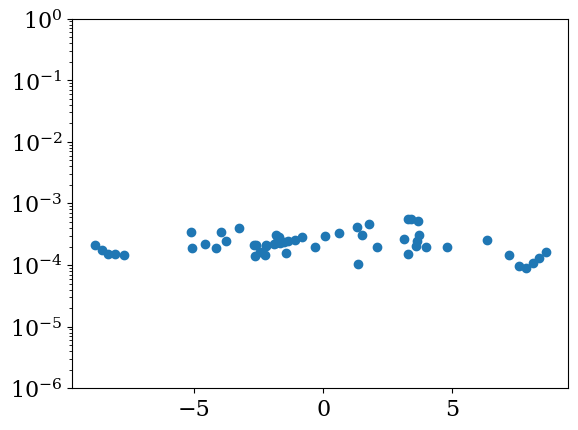

In [460]:
plt.plot( np.diagonal(x_elms)[:len(Kn)], Kn, marker='o', linestyle='none')
plt.yscale('log')

plt.ylim(1e-6,1e0)
